<a href="https://colab.research.google.com/github/ucaokylong/Some_small_projects/blob/main/Image_segmentation_Oxford_IIIT_Pet_Dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Đối với bài toán này, chúng ta sẽ xây dựng một mô hình Segmentation nhằm phân đoạn hình ảnh thú cưng (chó/mèo) từ tập dữ liệu Oxford-IIIT Pet Dataset. Mục tiêu của bài toán là tạo ra một mặt nạ (mask) phân đoạn, trong đó mỗi pixel được gán vào một trong ba lớp: Background (nền), Pet (vùng chứa thú cưng), Contour(đường viền phân tách giữa thú cưng và nền).

Bài toán segmentation này không chỉ giúp xác định rõ ràng vùng thú cưng trong ảnh mà còn là nền tảng để giải quyết các bài toán phức tạp hơn, như tách nền tự động, phân tích hình dáng, hoặc nhận diện giống loài.

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [15]:
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader

# Kích thước ảnh và số lớp
img_size = (128, 128)
num_classes = 3

# Transform cho ảnh đầu vào
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Transform cho nhãn/target
def target_transform(target):
    img = transforms.Resize(img_size)(target)
    img = transforms.functional.pil_to_tensor(img).squeeze_(0)
    img = img - 1
    img = img.to(torch.long)
    return img

# Dataset train và test
train_set = OxfordIIITPet(
    root="pets_data",
    split="trainval",
    target_types="segmentation",
    transform=transform,
    target_transform=target_transform,
    download=True
)

test_set = OxfordIIITPet(
    root="pets_data",
    split="test",
    target_types="segmentation",
    transform=transform,
    target_transform=target_transform,
    download=True
)

# DataLoader cho train và test
batch_size = 64

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=2
)


In [16]:
# Post processing
def de_normalize(img,
                 mean=(0.485, 0.456, 0.406),
                 std=(0.229, 0.224, 0.225)):
  result = img * std + mean
  result = np.clip(result, 0.0, 1.0)
  return result

In [17]:
# Xây dựng model
# Khối Convolutional
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv_block(x)
        return x


In [18]:
# Khối Encoder
class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.MaxPool2d(2),
            ConvBlock(in_channels, out_channels)
        )

    def forward(self, x):
        x = self.encoder(x)
        return x


In [19]:
# Khối Decoder
class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_trans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.conv_block = ConvBlock(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.conv_trans(x1)
        x = torch.cat([x2, x1], dim=1)
        x = self.conv_block(x)
        return x


In [20]:
# Xây dựng mô hình Unet
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Khởi tạo các khối trong U-Net
        self.in_conv = ConvBlock(n_channels, 64)

        self.enc_1 = Encoder(64, 128)
        self.enc_2 = Encoder(128, 256)
        self.enc_3 = Encoder(256, 512)
        self.enc_4 = Encoder(512, 1024)

        self.dec_1 = Decoder(1024, 512)
        self.dec_2 = Decoder(512, 256)
        self.dec_3 = Decoder(256, 128)
        self.dec_4 = Decoder(128, 64)

        # Convolution cuối cùng để đưa về số lớp đầu ra.
        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder path
        x1 = self.in_conv(x)

        x2 = self.enc_1(x1)
        x3 = self.enc_2(x2)
        x4 = self.enc_3(x3)
        x5 = self.enc_4(x4)

        # Decoder path với skip connections từ encoder.
        x = self.dec_1(x5, x4)
        x = self.dec_2(x, x3)
        x = self.dec_3(x, x2)
        x = self.dec_4(x, x1)

        # Đưa ra kết quả cuối cùng.
        x = self.out_conv(x)

        return x


In [21]:
# Thiết lập thiết bị (CPU hoặc GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Số lớp đầu ra
num_classes = 3  # OxfordIIITPet có 3 lớp: Background, Foreground, Boundaries

# Khởi tạo mô hình U-Net
model = UNet(n_channels=3, n_classes=num_classes).to(device)

# Số epoch tối đa để huấn luyện
max_epoch = 30

# Learning rate (tốc độ học)
LR = 0.001

# Hàm mất mát (Cross Entropy Loss cho bài toán phân đoạn nhiều lớp)
criterion = nn.CrossEntropyLoss()

# Bộ tối ưu hóa Adam
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [22]:
import matplotlib.pyplot as plt
import torch

@torch.inference_mode()
def display_prediction(model, image, target, device):
    """
    Hiển thị kết quả dự đoán của mô hình trên một ảnh đầu vào.

    Parameters:
    - model: Mô hình đã huấn luyện.
    - image: Ảnh đầu vào (tensor).
    - target: Ground truth (nhãn thực tế).
    - device: Thiết bị (CPU/GPU).

    Returns:
    - Hiển thị ảnh gốc, dự đoán và ground truth.
    """
    model.eval()
    img = image.unsqueeze(0).to(device)  # Thêm batch dimension và chuyển sang thiết bị

    output = model(img)  # Dự đoán từ mô hình
    pred = torch.argmax(output, dim=1).cpu().squeeze()  # Lấy nhãn có xác suất cao nhất

    plt.figure(figsize=(10, 5))

    # Ảnh gốc
    plt.subplot(1, 3, 1)
    plt.axis('off')
    plt.title("Input Image")
    plt.imshow(de_normalize(image.numpy().transpose(1, 2, 0)))

    # Kết quả dự đoán
    plt.subplot(1, 3, 2)
    plt.axis('off')
    plt.title("Prediction")
    plt.imshow(pred.numpy())

    # Ground truth
    plt.subplot(1, 3, 3)
    plt.axis('off')
    plt.title("Ground Truth")
    plt.imshow(target.numpy())

    plt.show()


In [23]:
def evaluate(model, test_loader, criterion):
    """
    Đánh giá mô hình trên tập dữ liệu kiểm tra.

    Parameters:
    - model: Mô hình đã huấn luyện.
    - test_loader: DataLoader chứa tập dữ liệu kiểm tra.
    - criterion: Hàm mất mát (loss function).

    Returns:
    - test_loss: Giá trị mất mát trung bình trên tập kiểm tra.
    """

    model.eval()  # Đặt mô hình ở chế độ đánh giá
    test_loss = 0.0

    with torch.no_grad():  # Tắt gradient để tiết kiệm bộ nhớ và tăng tốc độ
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Chuyển dữ liệu sang thiết bị

            outputs = model(inputs)  # Dự đoán từ mô hình
            loss = criterion(outputs, labels)  # Tính toán mất mát

            test_loss += loss.item()  # Cộng dồn giá trị mất mát

        test_loss = test_loss / len(test_loader)  # Tính trung bình mất mát

        return test_loss


Epoch [1/30], Training loss: 0.4423, Test Loss: 0.5469
Test image_80 after epoch 1: 


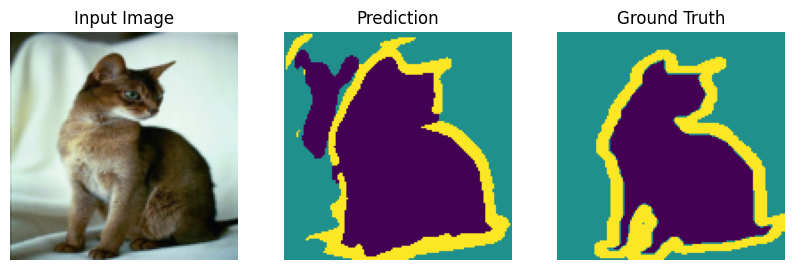

Epoch [2/30], Training loss: 0.4080, Test Loss: 0.4247
Test image_80 after epoch 2: 


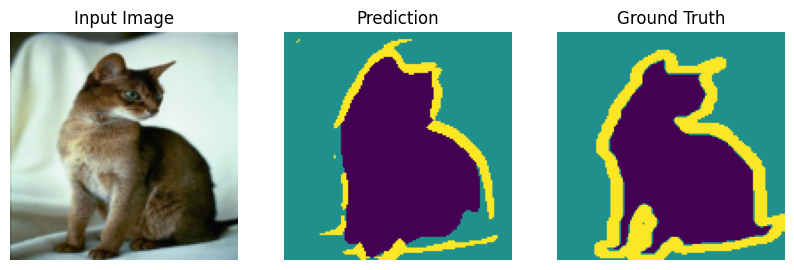

Epoch [3/30], Training loss: 0.3852, Test Loss: 0.3830
Test image_80 after epoch 3: 


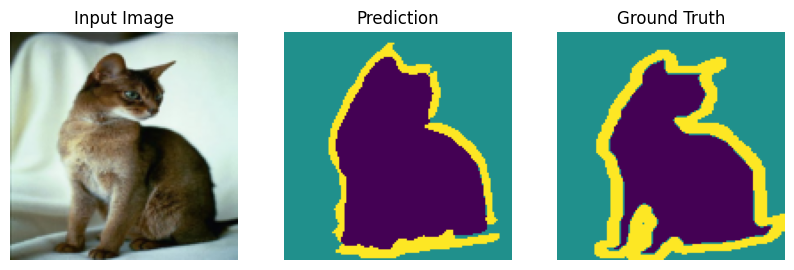

Epoch [4/30], Training loss: 0.3525, Test Loss: 0.3622
Test image_80 after epoch 4: 


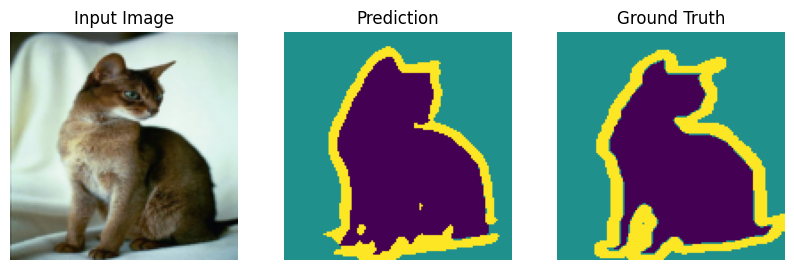

Epoch [5/30], Training loss: 0.3384, Test Loss: 0.3780
Test image_80 after epoch 5: 


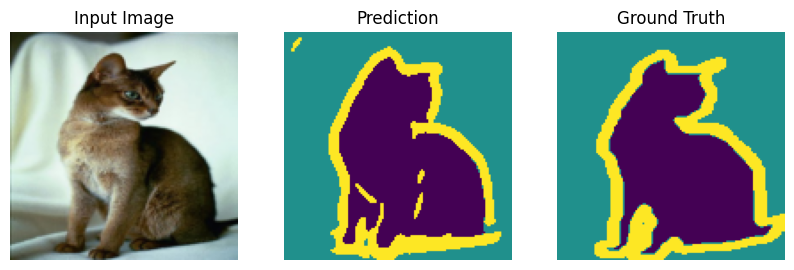

Epoch [6/30], Training loss: 0.3178, Test Loss: 0.3431
Test image_80 after epoch 6: 


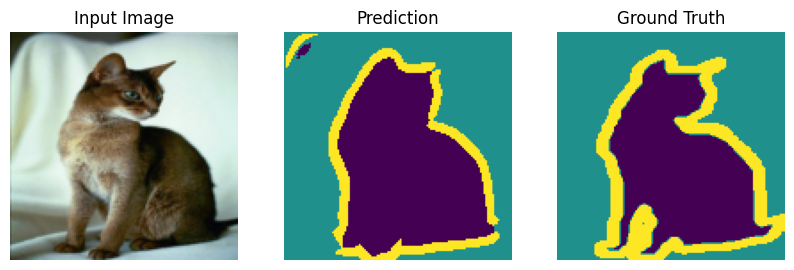

Epoch [7/30], Training loss: 0.3053, Test Loss: 0.3497
Test image_80 after epoch 7: 


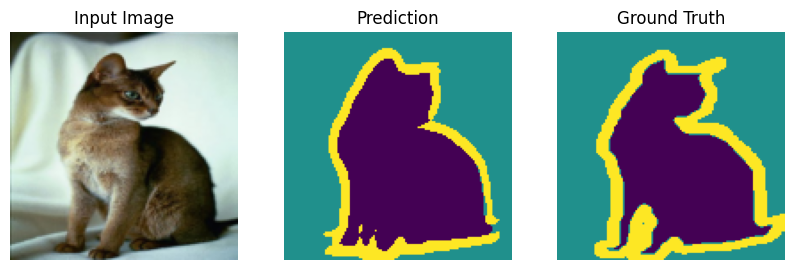

Epoch [8/30], Training loss: 0.2951, Test Loss: 0.3237
Test image_80 after epoch 8: 


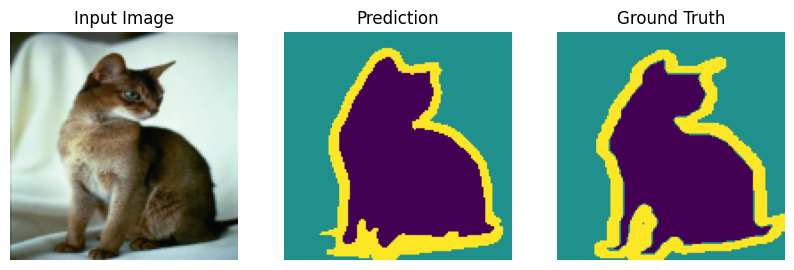

Epoch [9/30], Training loss: 0.2811, Test Loss: 0.3405
Test image_80 after epoch 9: 


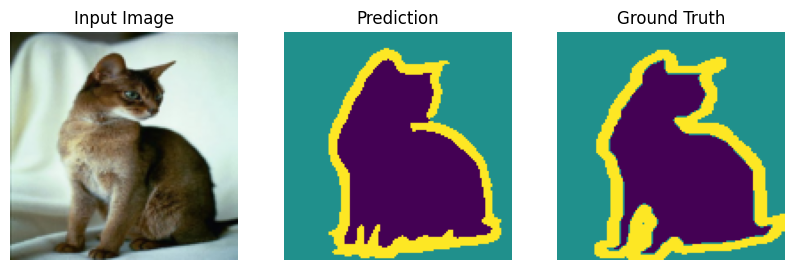

Epoch [10/30], Training loss: 0.2795, Test Loss: 0.3238
Test image_80 after epoch 10: 


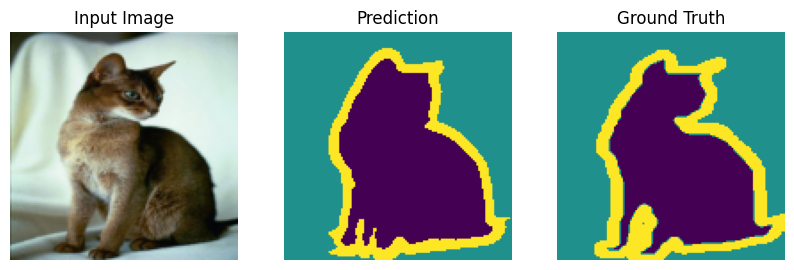

Epoch [11/30], Training loss: 0.2611, Test Loss: 0.3157
Test image_80 after epoch 11: 


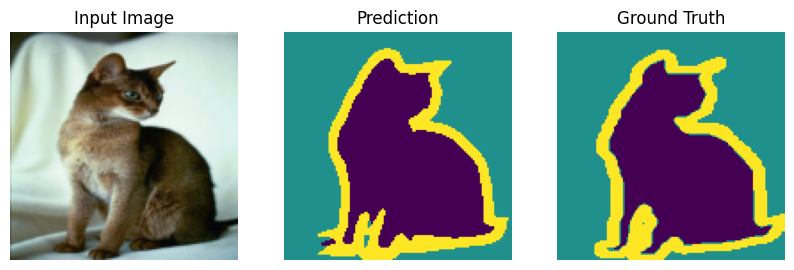

Epoch [12/30], Training loss: 0.2501, Test Loss: 0.2974
Test image_80 after epoch 12: 


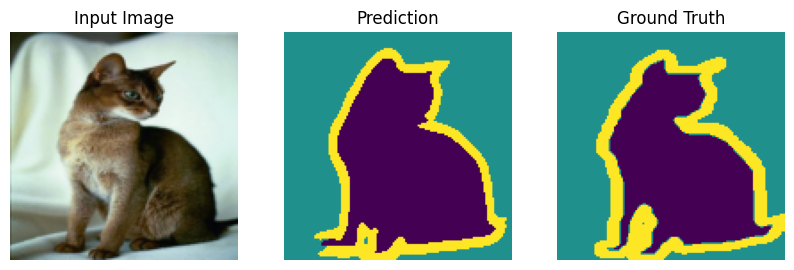

Epoch [13/30], Training loss: 0.2418, Test Loss: 0.3397
Test image_80 after epoch 13: 


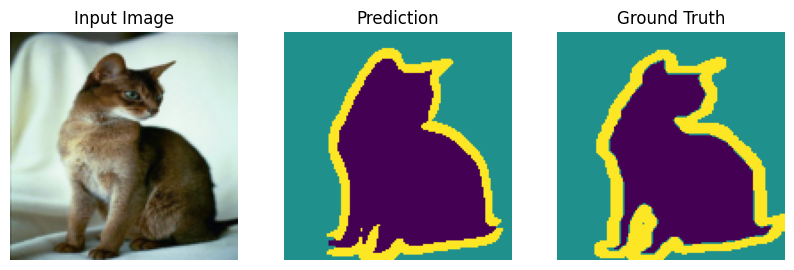

Epoch [14/30], Training loss: 0.2403, Test Loss: 0.3158
Test image_80 after epoch 14: 


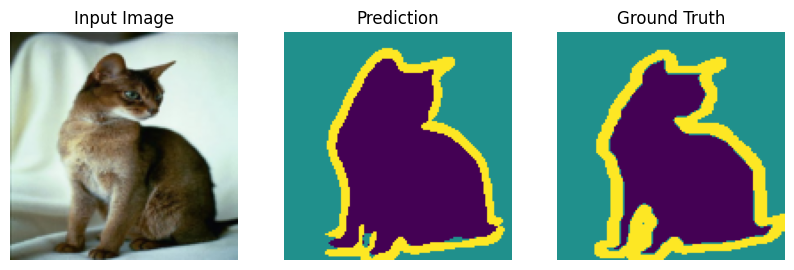

Epoch [15/30], Training loss: 0.2353, Test Loss: 0.3060
Test image_80 after epoch 15: 


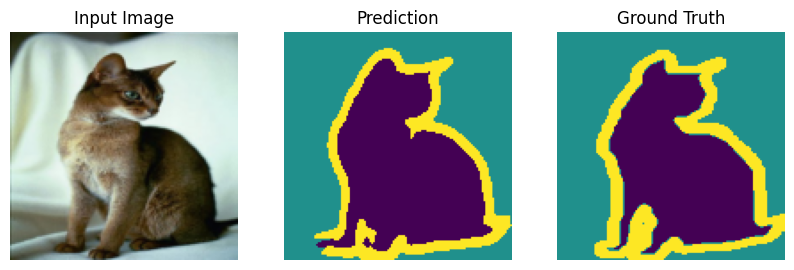

Epoch [16/30], Training loss: 0.2258, Test Loss: 0.2925
Test image_80 after epoch 16: 


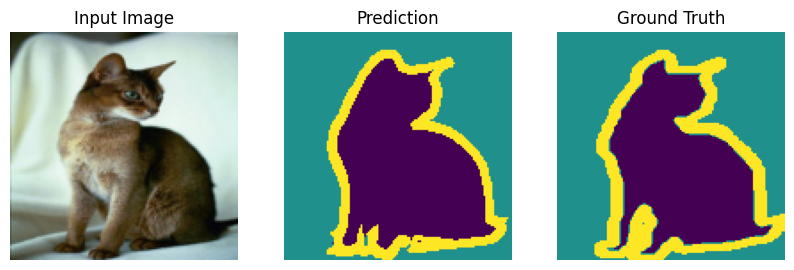

Epoch [17/30], Training loss: 0.2195, Test Loss: 0.2925
Test image_80 after epoch 17: 


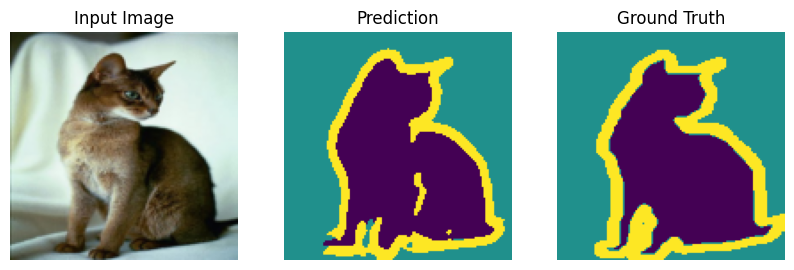

Epoch [18/30], Training loss: 0.2121, Test Loss: 0.3017
Test image_80 after epoch 18: 


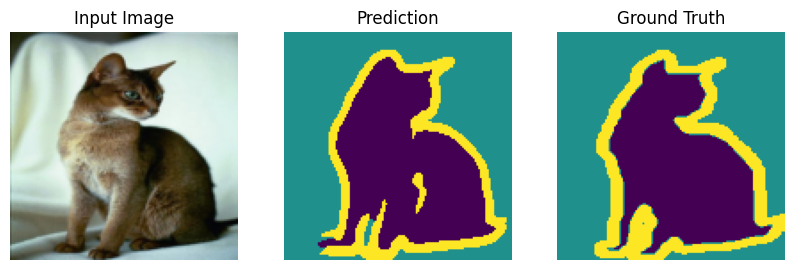

Epoch [19/30], Training loss: 0.2085, Test Loss: 0.3052
Test image_80 after epoch 19: 


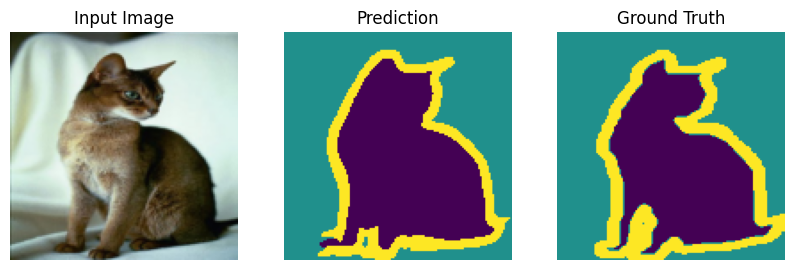

Epoch [20/30], Training loss: 0.2124, Test Loss: 0.3642
Test image_80 after epoch 20: 


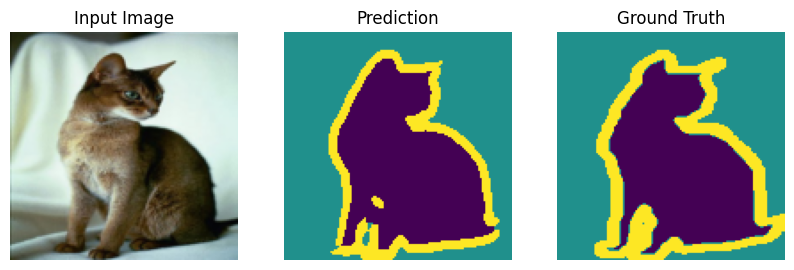

Epoch [21/30], Training loss: 0.2053, Test Loss: 0.3043
Test image_80 after epoch 21: 


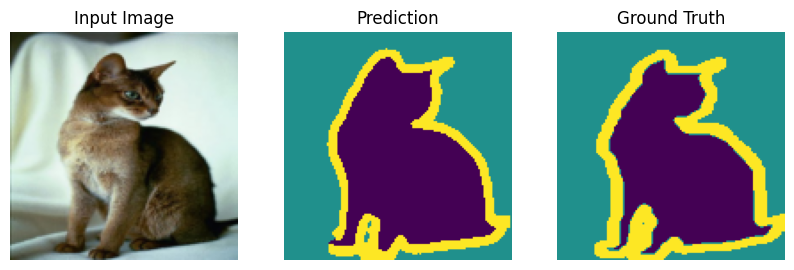

Epoch [22/30], Training loss: 0.1968, Test Loss: 0.3040
Test image_80 after epoch 22: 


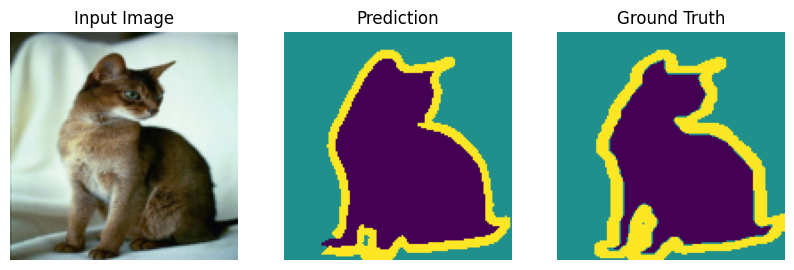

Epoch [23/30], Training loss: 0.1914, Test Loss: 0.3309
Test image_80 after epoch 23: 


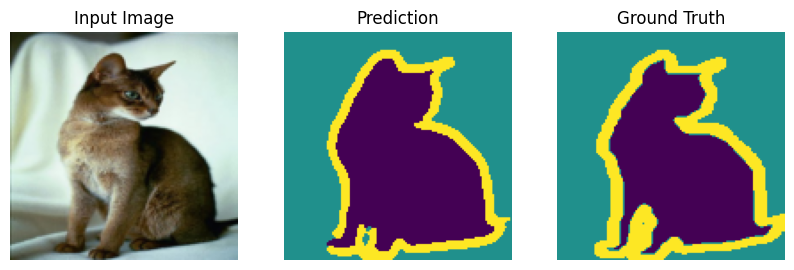

Epoch [24/30], Training loss: 0.1868, Test Loss: 0.3023
Test image_80 after epoch 24: 


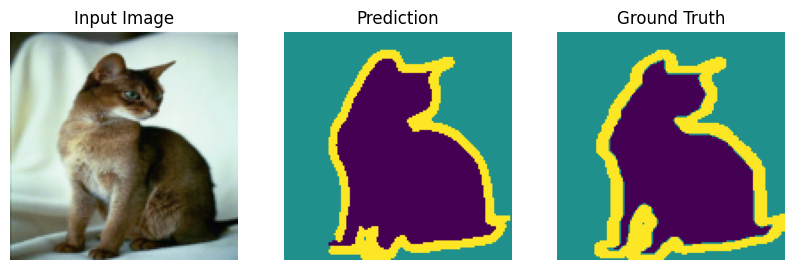

Epoch [25/30], Training loss: 0.1781, Test Loss: 0.3731
Test image_80 after epoch 25: 


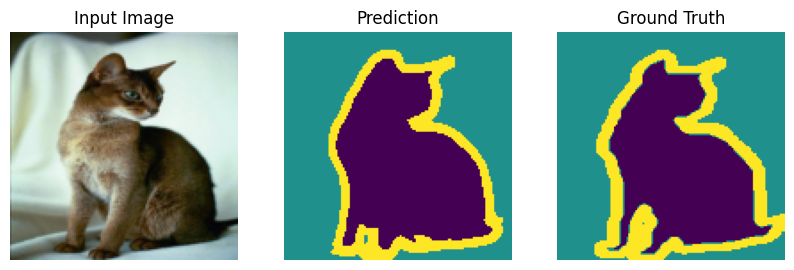

Epoch [26/30], Training loss: 0.1790, Test Loss: 0.3106
Test image_80 after epoch 26: 


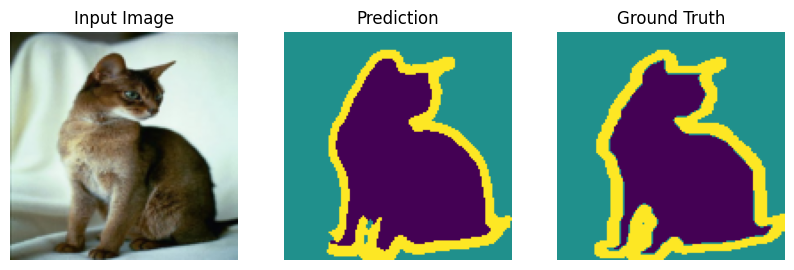

Epoch [27/30], Training loss: 0.1768, Test Loss: 0.3048
Test image_80 after epoch 27: 


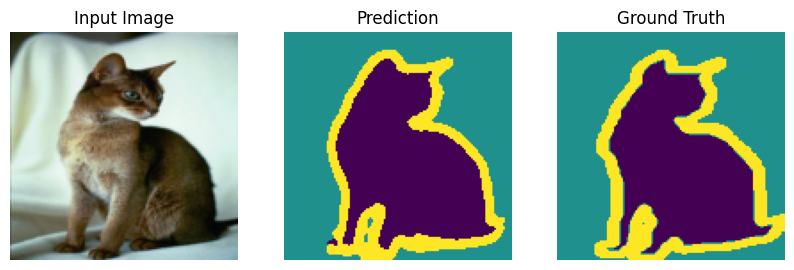

Epoch [28/30], Training loss: 0.1799, Test Loss: 0.3076
Test image_80 after epoch 28: 


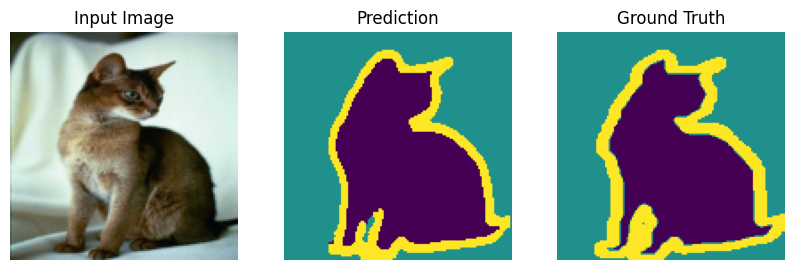

Epoch [29/30], Training loss: 0.1857, Test Loss: 0.3075
Test image_80 after epoch 29: 


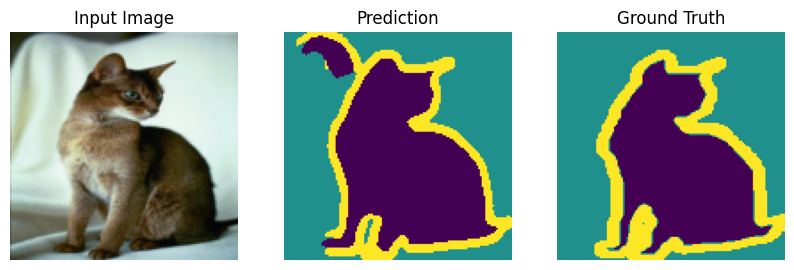

Epoch [30/30], Training loss: 0.1857, Test Loss: 0.2975
Test image_80 after epoch 30: 


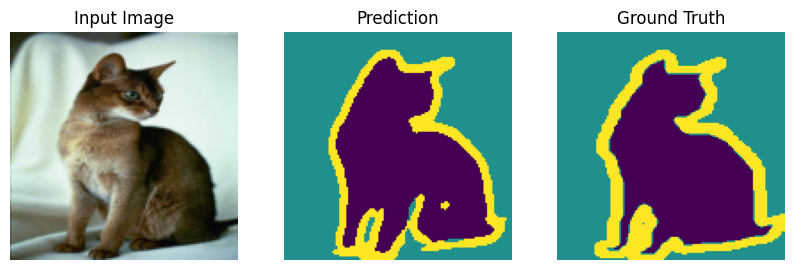

In [27]:
from tqdm import tqdm

test_index = 80
display_image = test_set[test_index][0].to(device)
display_target = test_set[test_index][1].to(device)

train_losses = []
test_losses = []
best_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

model.to(device)
for epoch in range(max_epoch):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{max_epoch}", leave=False)

    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        running_loss += loss.item()
        loss.backward()
        optimizer.step()

        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)
    test_loss = evaluate(model, test_loader, criterion)
    if test_loss < best_loss:
        best_loss = test_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch [{epoch + 1}/{max_epoch}], Training loss: {epoch_loss:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Test image_{test_index} after epoch {epoch+1}: ")

    # Chuyển về CPU trước khi truyền vào display_prediction
    display_prediction(model, display_image.cpu(), display_target.cpu(), device)

    train_losses.append(epoch_loss)
    test_losses.append(test_loss)


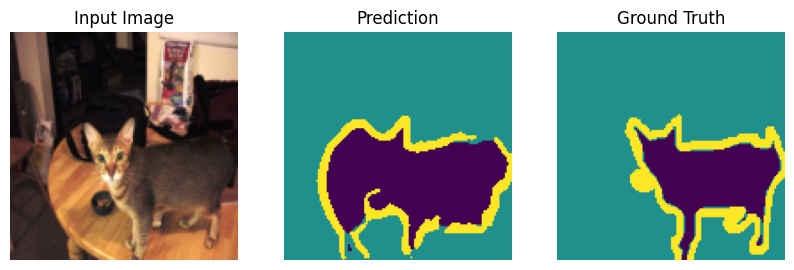

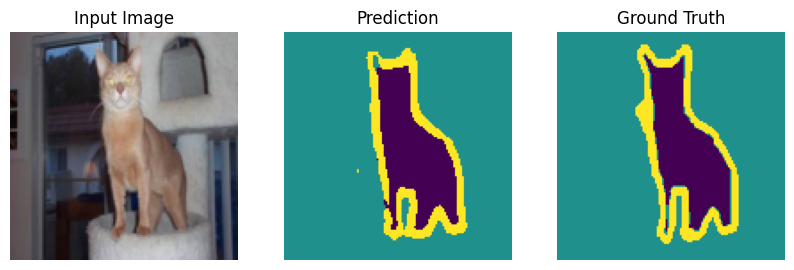

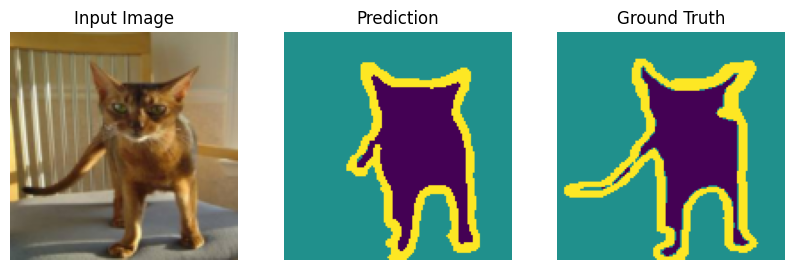

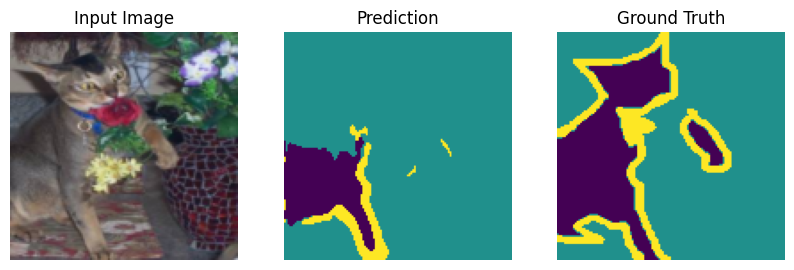

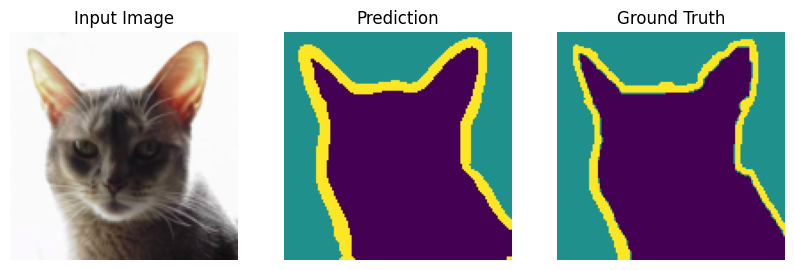

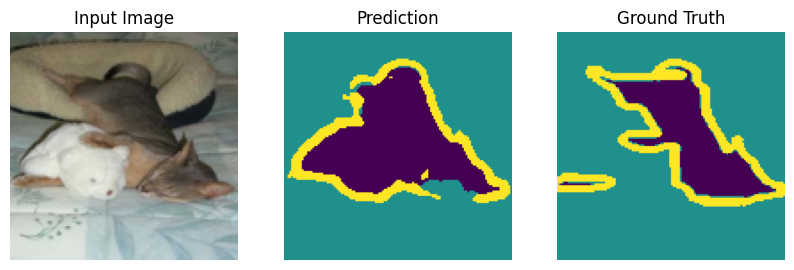

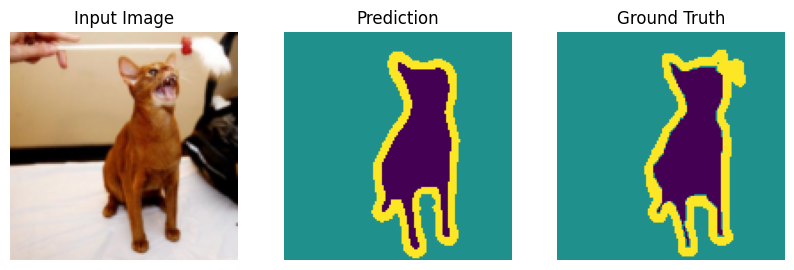

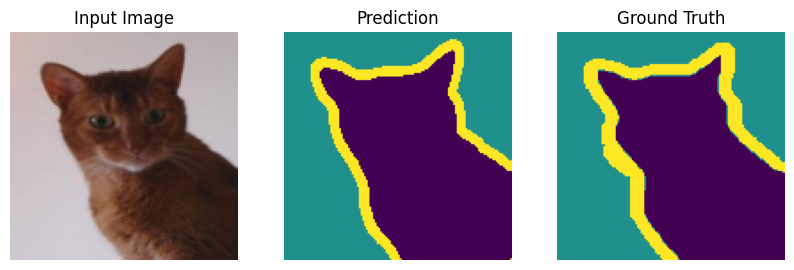

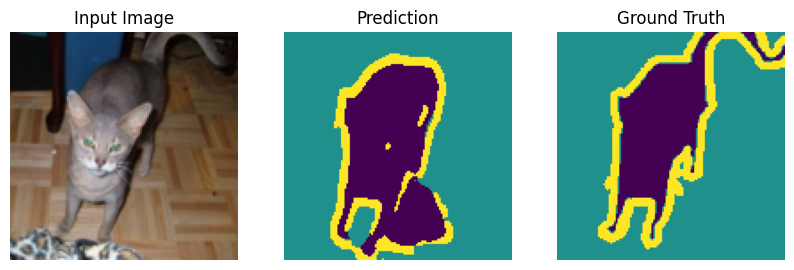

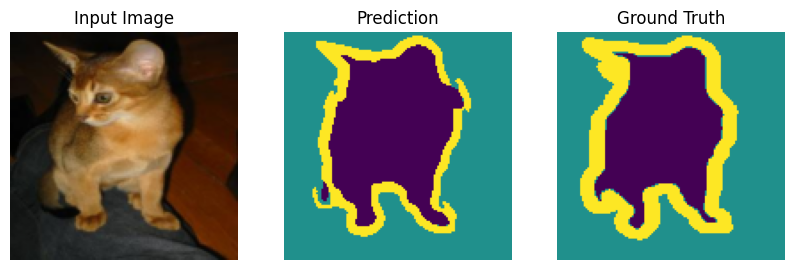

In [29]:
model.load_state_dict(best_model_wts)
n_test_points = 10
for i in range(n_test_points):
  img, gt = test_set[i]

  display_prediction(model, img, gt, device)